In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# ============================================
# PASTE YOUR CSV CONTENT HERE
# ============================================
# csv_text = """
# lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,ours_slo_e2e,irt_quality,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,num_prompts
# 0.0,0.6201376421304609,40.076678265308416,0.5258160237388724,0.7673590504451039,0.5246290801186944,0.5808523409363746,11.23782422705291,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.6222689075630252,37.53755809560374,0.6593471810089021,0.7181008902077152,0.6516320474777448,1685
# 0.1,0.6272155688622755,40.38539715633902,0.5204747774480712,0.7566765578635015,0.5169139465875371,0.5815726290516207,11.275116683326065,0.998813056379822,0.9922848664688427,0.9994065281899109,0.6257194244604317,38.48546507464672,0.6421364985163205,0.7364985163204748,0.6362017804154303,1685
# 0.2,0.6352007189934092,41.47106936253851,0.49970326409495547,0.7293768545994065,0.49258160237388726,0.5829136690647483,11.378277161284087,0.9982195845697329,0.9893175074183976,0.998813056379822,0.6278177458033573,38.88031403572694,0.6367952522255192,0.7287833827893175,0.629080118694362,1685
# 0.30000000000000004,0.6431995206710606,42.12752286715748,0.4890207715133531,0.7086053412462908,0.4807121661721068,0.5839232153569287,11.560377573471749,0.9982195845697329,0.9833827893175074,0.998813056379822,0.6330137807070102,39.61862716872897,0.6219584569732938,0.7151335311572701,0.6106824925816023,1685
# 0.4,0.6529976019184653,42.85872068518347,0.4807121661721068,0.6765578635014837,0.4658753709198813,0.5908573141486811,12.138439557389619,0.9934718100890207,0.9655786350148368,0.9916913946587537,0.6370281605751947,40.297443362725595,0.6059347181008902,0.6991097922848665,0.5922848664688427,1685
# 0.5,0.6572929171668669,43.88036790389336,0.4646884272997033,0.6581602373887241,0.44688427299703265,0.6061187762447511,14.42547649035468,0.971513353115727,0.9068249258160237,0.9614243323442137,0.6408273381294964,41.3100790255855,0.5875370919881305,0.6735905044510386,0.568545994065282,1685
# 0.6000000000000001,0.6691546762589928,44.68076875089538,0.4617210682492582,0.6166172106824925,0.4344213649851632,0.6332534451767526,18.823603577005404,0.9103857566765579,0.797032640949555,0.886053412462908,0.6554289142171567,42.243012139493,0.5691394658753709,0.6403560830860534,0.543026706231454,1685
# 0.7000000000000001,0.673247453565009,44.597793011566296,0.46943620178041545,0.5839762611275965,0.4373887240356083,0.6522768124625525,26.368185449990744,0.7952522255192879,0.6729970326409496,0.7554896142433234,0.6703836930455634,43.158901085697934,0.5448071216617211,0.5887240356083087,0.5091988130563798,1685
# 0.8,0.6776213301378071,44.333433503849925,0.4836795252225519,0.5382789317507418,0.4427299703264095,0.6742070616397366,33.870652821792696,0.6718100890207716,0.5483679525222552,0.6201780415430267,0.6791442250149612,43.686225604445006,0.5305637982195845,0.5311572700296736,0.4801186943620178,1685
# 0.9,0.6836826347305389,43.835100579332526,0.5002967359050445,0.4771513353115727,0.4433234421364985,0.6813473053892216,39.33634901683479,0.5857566765578635,0.4658753709198813,0.5252225519287834,0.6829041916167665,43.93495936903119,0.5210682492581602,0.4658753709198813,0.4599406528189911,1685
# 1.0,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,1685
# """

# csv_text = """
# lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,ours_slo_e2e,irt_quality,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,umr_quality,umr_latency,umr_slo_ttft,umr_slo_tpot,umr_slo_e2e,num_prompts
# 0.0,0.6201376421304609,40.076678265308416,0.5258160237388724,0.7673590504451039,0.5246290801186944,0.5808523409363746,11.23782422705291,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.6222689075630252,37.53755809560374,0.6593471810089021,0.7181008902077152,0.6516320474777448,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.1,0.6272155688622755,40.38539715633902,0.5204747774480712,0.7566765578635015,0.5169139465875371,0.5815726290516207,11.275116683326065,0.998813056379822,0.9922848664688427,0.9994065281899109,0.6257194244604317,38.48546507464672,0.6421364985163205,0.7364985163204748,0.6362017804154303,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.2,0.6352007189934092,41.47106936253851,0.49970326409495547,0.7293768545994065,0.49258160237388726,0.5829136690647483,11.378277161284087,0.9982195845697329,0.9893175074183976,0.998813056379822,0.6278177458033573,38.88031403572694,0.6367952522255192,0.7287833827893175,0.629080118694362,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.30000000000000004,0.6431995206710606,42.12752286715748,0.4890207715133531,0.7086053412462908,0.4807121661721068,0.5839232153569287,11.560377573471749,0.9982195845697329,0.9833827893175074,0.998813056379822,0.6330137807070102,39.61862716872897,0.6219584569732938,0.7151335311572701,0.6106824925816023,0.5597897897897899,21.72828354071439,0.9875370919881306,0.7388724035608308,0.9727002967359051,1685
# 0.4,0.6529976019184653,42.85872068518347,0.4807121661721068,0.6765578635014837,0.4658753709198813,0.5908573141486811,12.138439557389619,0.9934718100890207,0.9655786350148368,0.9916913946587537,0.6370281605751947,40.297443362725595,0.6059347181008902,0.6991097922848665,0.5922848664688427,0.5661455201443175,20.676750269558735,0.9887240356083086,0.7679525222551928,0.9750741839762611,1685
# 0.5,0.6572929171668669,43.88036790389336,0.4646884272997033,0.6581602373887241,0.44688427299703265,0.6061187762447511,14.42547649035468,0.971513353115727,0.9068249258160237,0.9614243323442137,0.6408273381294964,41.3100790255855,0.5875370919881305,0.6735905044510386,0.568545994065282,0.5676488274203247,20.222050628039533,0.9899109792284867,0.7744807121661721,0.9768545994065282,1685
# 0.6000000000000001,0.6691546762589928,44.68076875089538,0.4617210682492582,0.6166172106824925,0.4344213649851632,0.6332534451767526,18.823603577005404,0.9103857566765579,0.797032640949555,0.886053412462908,0.6554289142171567,42.243012139493,0.5691394658753709,0.6403560830860534,0.543026706231454,0.5677390258568852,19.8137674760394,0.9905044510385757,0.7845697329376855,0.9780415430267062,1685
# 0.7000000000000001,0.673247453565009,44.597793011566296,0.46943620178041545,0.5839762611275965,0.4373887240356083,0.6522768124625525,26.368185449990744,0.7952522255192879,0.6729970326409496,0.7554896142433234,0.6703836930455634,43.158901085697934,0.5448071216617211,0.5887240356083087,0.5091988130563798,0.5867107636800962,18.2160215260367,0.9513353115727003,0.8718100890207715,0.9448071216617211,1685
# 0.8,0.6776213301378071,44.333433503849925,0.4836795252225519,0.5382789317507418,0.4427299703264095,0.6742070616397366,33.870652821792696,0.6718100890207716,0.5483679525222552,0.6201780415430267,0.6791442250149612,43.686225604445006,0.5305637982195845,0.5311572700296736,0.4801186943620178,0.63981981981982,25.92976846567601,0.829673590504451,0.6439169139465876,0.7934718100890208,1685
# 0.9,0.6836826347305389,43.835100579332526,0.5002967359050445,0.4771513353115727,0.4433234421364985,0.6813473053892216,39.33634901683479,0.5857566765578635,0.4658753709198813,0.5252225519287834,0.6829041916167665,43.93495936903119,0.5210682492581602,0.4658753709198813,0.4599406528189911,0.6787987987987987,41.95861403694492,0.5270029673590505,0.48427299703264093,0.47774480712166173,1685
# 1.0,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,1685
# """

# csv_text = """lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,ours_slo_e2e,irt_quality,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,umr_quality,umr_latency,umr_slo_ttft,umr_slo_tpot,umr_slo_e2e,num_prompts
# 0.0,0.6201376421304609,40.076678265308416,0.5258160237388724,0.7673590504451039,0.5246290801186944,0.5808523409363746,11.23782422705291,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.6222689075630252,37.53755809560374,0.6593471810089021,0.7181008902077152,0.6516320474777448,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.1,0.6272155688622755,40.38539715633902,0.5204747774480712,0.7566765578635015,0.5169139465875371,0.5830432172869148,11.274533268676667,0.9994065281899109,0.9910979228486647,0.9994065281899109,0.6257194244604317,38.48546507464672,0.6421364985163205,0.7364985163204748,0.6362017804154303,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.2,0.6352007189934092,41.47106936253851,0.49970326409495547,0.7293768545994065,0.49258160237388726,0.5831235011990408,11.325979540256082,0.998813056379822,0.9875370919881306,0.998813056379822,0.6278177458033573,38.88031403572694,0.6367952522255192,0.7287833827893175,0.629080118694362,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.30000000000000004,0.6431995206710606,42.12752286715748,0.4890207715133531,0.7086053412462908,0.4807121661721068,0.5845323741007195,11.509312619087604,0.9964391691394658,0.9827893175074184,0.9964391691394658,0.6330137807070102,39.61862716872897,0.6219584569732938,0.7151335311572701,0.6106824925816023,0.5597897897897899,21.72828354071439,0.9875370919881306,0.7388724035608308,0.9727002967359051,1685
# 0.4,0.6529976019184653,42.85872068518347,0.4807121661721068,0.6765578635014837,0.4658753709198813,0.5954136690647482,13.811092515090806,0.9637982195845697,0.9554896142433235,0.9620178041543027,0.6370281605751947,40.297443362725595,0.6059347181008902,0.6991097922848665,0.5922848664688427,0.5661455201443175,20.676750269558735,0.9887240356083086,0.7679525222551928,0.9750741839762611,1685
# 0.5,0.6572929171668669,43.88036790389336,0.4646884272997033,0.6581602373887241,0.44688427299703265,0.6156381066506891,16.69460500935065,0.9258160237388724,0.886053412462908,0.91513353115727,0.6408273381294964,41.3100790255855,0.5875370919881305,0.6735905044510386,0.568545994065282,0.5676488274203247,20.222050628039533,0.9899109792284867,0.7744807121661721,0.9768545994065282,1685
# 0.6000000000000001,0.6691546762589928,44.68076875089538,0.4617210682492582,0.6166172106824925,0.4344213649851632,0.6416467065868264,21.545900984404703,0.8605341246290801,0.7543026706231454,0.8338278931750742,0.6554289142171567,42.243012139493,0.5691394658753709,0.6403560830860534,0.543026706231454,0.5677390258568852,19.8137674760394,0.9905044510385757,0.7845697329376855,0.9780415430267062,1685
# 0.7000000000000001,0.673247453565009,44.597793011566296,0.46943620178041545,0.5839762611275965,0.4373887240356083,0.6656193895870738,28.80097321218836,0.7477744807121661,0.6124629080118694,0.7068249258160237,0.6703836930455634,43.158901085697934,0.5448071216617211,0.5887240356083087,0.5091988130563798,0.5867107636800962,18.2160215260367,0.9513353115727003,0.8718100890207715,0.9448071216617211,1685
# 0.8,0.6776213301378071,44.333433503849925,0.4836795252225519,0.5382789317507418,0.4427299703264095,0.6850808867585381,36.795158352979215,0.6207715133531158,0.486646884272997,0.5679525222551929,0.6791442250149612,43.686225604445006,0.5305637982195845,0.5311572700296736,0.4801186943620178,0.63981981981982,25.92976846567601,0.829673590504451,0.6439169139465876,0.7934718100890208,1685
# 0.9,0.6836826347305389,43.835100579332526,0.5002967359050445,0.4771513353115727,0.4433234421364985,0.6931695626123427,43.96460362725866,0.5068249258160238,0.4089020771513353,0.44510385756676557,0.6829041916167665,43.93495936903119,0.5210682492581602,0.4658753709198813,0.4599406528189911,0.6787987987987987,41.95861403694492,0.5270029673590505,0.48427299703264093,0.47774480712166173,1685
# 1.0,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,1685
# """

# csv_text = """lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,ours_slo_e2e,irt_quality,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,umr_quality,umr_latency,umr_slo_ttft,umr_slo_tpot,umr_slo_e2e,num_prompts
# 0.0,0.6201376421304609,40.076678265308416,0.5258160237388724,0.7673590504451039,0.5246290801186944,0.5808523409363746,11.23782422705291,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.1,0.6272155688622755,40.38539715633902,0.5204747774480712,0.7566765578635015,0.5169139465875371,0.5830432172869148,11.274533268676667,0.9994065281899109,0.9910979228486647,0.9994065281899109,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.2,0.6352007189934092,41.47106936253851,0.49970326409495547,0.7293768545994065,0.49258160237388726,0.5831235011990408,11.325979540256082,0.998813056379822,0.9875370919881306,0.998813056379822,0.5251351351351351,24.196877748959142,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
# 0.30000000000000004,0.6431995206710606,42.12752286715748,0.4890207715133531,0.7086053412462908,0.4807121661721068,0.5845323741007195,11.509312619087604,0.9964391691394658,0.9827893175074184,0.9964391691394658,0.5411711711711712,23.596386586310956,0.9851632047477745,0.6979228486646885,0.9679525222551929,0.5597897897897899,21.72828354071439,0.9875370919881306,0.7388724035608308,0.9727002967359051,1685
# 0.4,0.6529976019184653,42.85872068518347,0.4807121661721068,0.6765578635014837,0.4658753709198813,0.5954136690647482,13.811092515090806,0.9637982195845697,0.9554896142433235,0.9620178041543027,0.5630630630630631,22.07984904945781,0.9875370919881306,0.743620178041543,0.9727002967359051,0.5661455201443175,20.676750269558735,0.9887240356083086,0.7679525222551928,0.9750741839762611,1685
# 0.5,0.6572929171668669,43.88036790389336,0.4646884272997033,0.6581602373887241,0.44688427299703265,0.6156381066506891,16.69460500935065,0.9258160237388724,0.886053412462908,0.91513353115727,0.576754649070186,20.067366543863223,0.9899109792284867,0.7887240356083086,0.9768545994065282,0.5676488274203247,20.222050628039533,0.9899109792284867,0.7744807121661721,0.9768545994065282,1685
# 0.6000000000000001,0.6691546762589928,44.68076875089538,0.4617210682492582,0.6166172106824925,0.4344213649851632,0.6416467065868264,21.545900984404703,0.8605341246290801,0.7543026706231454,0.8338278931750742,0.5889622075584883,18.058695886679857,0.9922848664688427,0.8391691394658753,0.9827893175074184,0.5677390258568852,19.8137674760394,0.9905044510385757,0.7845697329376855,0.9780415430267062,1685
# 0.7000000000000001,0.673247453565009,44.597793011566296,0.46943620178041545,0.5839762611275965,0.4373887240356083,0.6656193895870738,28.80097321218836,0.7477744807121661,0.6124629080118694,0.7068249258160237,0.5951409718056389,16.83954040388679,0.9928783382789318,0.8712166172106824,0.9863501483679525,0.5867107636800962,18.2160215260367,0.9513353115727003,0.8718100890207715,0.9448071216617211,1685
# 0.8,0.6776213301378071,44.333433503849925,0.4836795252225519,0.5382789317507418,0.4427299703264095,0.6850808867585381,36.795158352979215,0.6207715133531158,0.486646884272997,0.5679525222551929,0.6132132132132133,17.94327612050563,0.9560830860534124,0.8397626112759644,0.9412462908011869,0.63981981981982,25.92976846567601,0.829673590504451,0.6439169139465876,0.7934718100890208,1685
# 0.9,0.6836826347305389,43.835100579332526,0.5002967359050445,0.4771513353115727,0.4433234421364985,0.6931695626123427,43.96460362725866,0.5068249258160238,0.4089020771513353,0.44510385756676557,0.6716127098321343,33.47574920668446,0.6771513353115727,0.5916913946587538,0.629673590504451,0.6787987987987987,41.95861403694492,0.5270029673590505,0.48427299703264093,0.47774480712166173,1685
# 1.0,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,0.694511097780444,45.45306075447037,0.4908011869436202,0.3264094955489614,0.4029673590504451,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,1685
# """

csv_text = """lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,ours_slo_e2e,irt_quality,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,umr_quality,umr_latency,umr_slo_ttft,umr_slo_tpot,umr_slo_e2e,num_prompts
0.0,0.6201376421304609,40.076678265308416,0.5258160237388724,0.7673590504451039,0.5246290801186944,0.5808523409363746,11.23782422705291,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
0.1,0.6272155688622755,40.38539715633902,0.5204747774480712,0.7566765578635015,0.5169139465875371,0.581452581032413,11.22634806010419,0.9994065281899109,0.9934718100890207,0.9994065281899109,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
0.2,0.6352007189934092,41.47106936253851,0.49970326409495547,0.7293768545994065,0.49258160237388726,0.5834633853541417,11.247335988477712,0.9994065281899109,0.9916913946587537,0.9994065281899109,0.5251351351351351,24.196877748959142,0.9851632047477745,0.6824925816023739,0.9673590504451038,0.5251351351351351,24.220391726281594,0.9851632047477745,0.6824925816023739,0.9673590504451038,1685
0.30000000000000004,0.6431995206710606,42.12752286715748,0.4890207715133531,0.7086053412462908,0.4807121661721068,0.5831235011990408,11.255623419843724,0.998813056379822,0.9899109792284867,0.998813056379822,0.5411711711711712,23.596386586310956,0.9851632047477745,0.6979228486646885,0.9679525222551929,0.5597897897897899,21.72828354071439,0.9875370919881306,0.7388724035608308,0.9727002967359051,1685
0.4,0.6529976019184653,42.85872068518347,0.4807121661721068,0.6765578635014837,0.4658753709198813,0.5848021582733813,11.43339963638464,0.9982195845697329,0.9827893175074184,0.997626112759644,0.5630630630630631,22.07984904945781,0.9875370919881306,0.743620178041543,0.9727002967359051,0.5661455201443175,20.676750269558735,0.9887240356083086,0.7679525222551928,0.9750741839762611,1685
0.5,0.6572929171668669,43.88036790389336,0.4646884272997033,0.6581602373887241,0.44688427299703265,0.6059052757793766,12.859106301129394,0.9881305637982196,0.9252225519287833,0.9792284866468842,0.576754649070186,20.067366543863223,0.9899109792284867,0.7887240356083086,0.9768545994065282,0.5676488274203247,20.222050628039533,0.9899109792284867,0.7744807121661721,0.9768545994065282,1685
0.6000000000000001,0.6691546762589928,44.68076875089538,0.4617210682492582,0.6166172106824925,0.4344213649851632,0.631733653269346,19.071333725586843,0.8949554896142433,0.7839762611275964,0.8682492581602373,0.5889622075584883,18.058695886679857,0.9922848664688427,0.8391691394658753,0.9827893175074184,0.5677390258568852,19.8137674760394,0.9905044510385757,0.7845697329376855,0.9780415430267062,1685
0.7000000000000001,0.673247453565009,44.597793011566296,0.46943620178041545,0.5839762611275965,0.4373887240356083,0.6483483483483483,22.954308549303683,0.8391691394658753,0.7181008902077152,0.8041543026706232,0.5951409718056389,16.83954040388679,0.9928783382789318,0.8712166172106824,0.9863501483679525,0.5867107636800962,18.2160215260367,0.9513353115727003,0.8718100890207715,0.9448071216617211,1685
0.8,0.6776213301378071,44.333433503849925,0.4836795252225519,0.5382789317507418,0.4427299703264095,0.676648681055156,30.566453261898957,0.7323442136498516,0.5928783382789318,0.686053412462908,0.6132132132132133,17.94327612050563,0.9560830860534124,0.8397626112759644,0.9412462908011869,0.63981981981982,25.92976846567601,0.829673590504451,0.6439169139465876,0.7934718100890208,1685
0.9,0.6836826347305389,43.835100579332526,0.5002967359050445,0.4771513353115727,0.4433234421364985,0.6962829736211031,42.90228831279879,0.5347181008902078,0.3857566765578635,0.4611275964391691,0.6716127098321343,33.47574920668446,0.6771513353115727,0.5916913946587538,0.629673590504451,0.6787987987987987,41.95861403694492,0.5270029673590505,0.48427299703264093,0.47774480712166173,1685
1.0,0.6866467065868264,43.00985777441755,0.5287833827893175,0.4130563798219585,0.4593471810089021,0.694511097780444,45.45306075447037,0.4908011869436202,0.3264094955489614,0.4029673590504451,0.694511097780444,45.45306075447037,0.4908011869436202,0.3264094955489614,0.4029673590504451,0.6949610077984403,45.73612307922069,0.486646884272997,0.3074183976261128,0.40712166172106823,1685
"""

# ============================================
# Load from text
# ============================================
df = pd.read_csv(StringIO(csv_text))

sns.set(style="whitegrid", font_scale=1.4)

print("Loaded dataframe:")
df


Loaded dataframe:


,lambda,carrot_quality,carrot_latency,carrot_slo_ttft,carrot_slo_tpot,carrot_slo_e2e,ours_quality,ours_latency,ours_slo_ttft,ours_slo_tpot,...,irt_latency,irt_slo_ttft,irt_slo_tpot,irt_slo_e2e,umr_quality,umr_latency,umr_slo_ttft,umr_slo_tpot,umr_slo_e2e,num_prompts
0,0.0,0.620138,40.076678,0.525816,0.767359,0.524629,0.580852,11.237824,0.999407,0.993472,...,24.220392,0.985163,0.682493,0.967359,0.525135,24.220392,0.985163,0.682493,0.967359,1685
1,0.1,0.627216,40.385397,0.520475,0.756677,0.516914,0.581453,11.226348,0.999407,0.993472,...,24.220392,0.985163,0.682493,0.967359,0.525135,24.220392,0.985163,0.682493,0.967359,1685
2,0.2,0.635201,41.471069,0.499703,0.729377,0.492582,0.583463,11.247336,0.999407,0.991691,...,24.196878,0.985163,0.682493,0.967359,0.525135,24.220392,0.985163,0.682493,0.967359,1685
3,0.3,0.643200,42.127523,0.489021,0.708605,0.480712,0.583124,11.255623,0.998813,0.989911,...,23.596387,0.985163,0.697923,0.967953,0.559790,21.728284,0.987537,0.738872,0.972700,1685
4,0.4,0.652998,42.858721,0.480712,0.676558,0.465875,0.584802,11.433400,0.998220,0.982789,...,22.079849,0.987537,0.743620,0.972700,0.566146,20.676750,0.988724,0.767953,0.975074,1685
5,0.5,0.657293,43.880368,0.464688,0.658160,0.446884,0.605905,12.859106,0.988131,0.925223,...,20.067367,0.989911,0.788724,0.976855,0.567649,20.222051,0.989911,0.774481,0.976855,1685
6,0.6,0.669155,44.680769,0.461721,0.616617,0.434421,0.631734,19.071334,0.894955,0.783976,...,18.058696,0.992285,0.839169,0.982789,0.567739,19.813767,0.990504,0.784570,0.978042,1685
7,0.7,0.673247,44.597793,0.469436,0.583976,0.437389,0.648348,22.954309,0.839169,0.718101,...,16.839540,0.992878,0.871217,0.986350,0.586711,18.216022,0.951335,0.871810,0.944807,1685
8,0.8,0.677621,44.333434,0.483680,0.538279,0.442730,0.676649,30.566453,0.732344,0.592878,...,17.943276,0.956083,0.839763,0.941246,0.639820,25.929768,0.829674,0.643917,0.793472,1685
9,0.9,0.683683,43.835101,0.500297,0.477151,0.443323,0.696283,42.902288,0.534718,0.385757,...,33.475749,0.677151,0.591691,0.629674,0.678799,41.958614,0.527003,0.484273,0.477745,1685


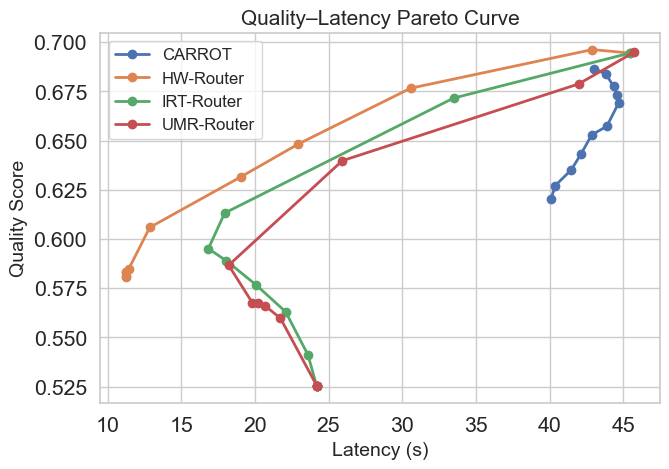

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    df["carrot_latency"], df["carrot_quality"],
    marker="o", markersize=6, linewidth=2.0,
    label="CARROT"
)

plt.plot(
    df["ours_latency"], df["ours_quality"],
    marker="o", markersize=6, linewidth=2.0,
    label="HW-Router"
)

plt.plot(
    df["irt_latency"], df["irt_quality"],
    marker="o", markersize=6, linewidth=2.0,
    label="IRT-Router"
)

plt.plot(
    df["umr_latency"], df["umr_quality"],
    marker="o", markersize=6, linewidth=2.0,
    label="UMR-Router"
)

plt.xlabel("Latency (s)", fontsize=14)
plt.ylabel("Quality Score", fontsize=14)
plt.title("Quality–Latency Pareto Curve", fontsize=15)

plt.legend(fontsize=12)
plt.tight_layout()

# plt.savefig(
#     "/home/ahasan/projects/hardware-aware-router/data/figures/pareto_curve.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

plt.show()


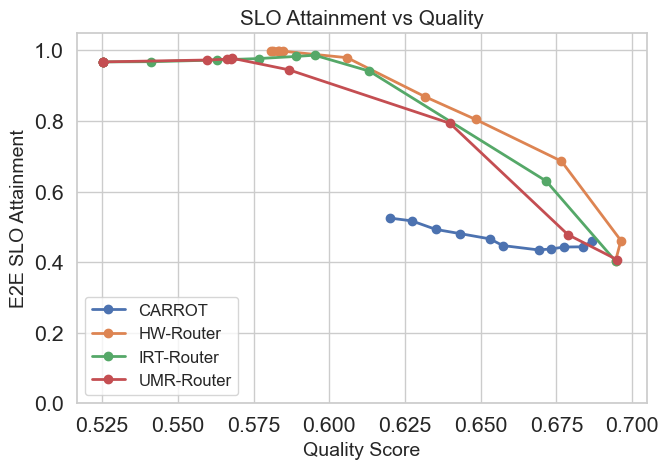

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    df["carrot_quality"], df["carrot_slo_e2e"],
    marker="o", markersize=6, linewidth=2.0,
    label="CARROT"
)

plt.plot(
    df["ours_quality"], df["ours_slo_e2e"],
    marker="o", markersize=6, linewidth=2.0,
    label="HW-Router"
)

plt.plot(
    df["irt_quality"], df["irt_slo_e2e"],
    marker="o", markersize=6, linewidth=2.0,
    label="IRT-Router"
)

plt.plot(
    df["umr_quality"], df["umr_slo_e2e"],
    marker="o", markersize=6, linewidth=2.0,
    label="UMR-Router"
)

plt.xlabel("Quality Score", fontsize=14)
plt.ylabel("E2E SLO Attainment", fontsize=14)
plt.title("SLO Attainment vs Quality", fontsize=15)

plt.ylim(0, 1.05)
plt.legend(fontsize=12)
plt.tight_layout()

# plt.savefig(
#     "/home/ahasan/projects/hardware-aware-router/data/figures/slo_e2e_vs_quality.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

plt.show()


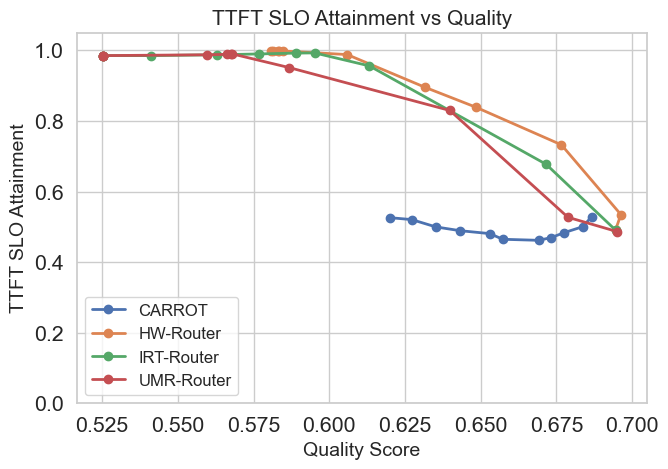

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    df["carrot_quality"], df["carrot_slo_ttft"],
    marker="o", markersize=6, linewidth=2.0,
    label="CARROT"
)

plt.plot(
    df["ours_quality"], df["ours_slo_ttft"],
    marker="o", markersize=6, linewidth=2.0,
    label="HW-Router"
)

plt.plot(
    df["irt_quality"], df["irt_slo_ttft"],
    marker="o", markersize=6, linewidth=2.0,
    label="IRT-Router"
)

plt.plot(
    df["umr_quality"], df["umr_slo_ttft"],
    marker="o", markersize=6, linewidth=2.0,
    label="UMR-Router"
)

plt.xlabel("Quality Score", fontsize=14)
plt.ylabel("TTFT SLO Attainment", fontsize=14)
plt.title("TTFT SLO Attainment vs Quality", fontsize=15)

plt.ylim(0, 1.05)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(
    "/home/ahasan/projects/hardware-aware-router/data/figures/slo_ttft_vs_quality.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
